In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [2]:

# Path to the Kaggle dataset
dataset_path = "data/news.json"

# Load the dataset
df = pd.read_json(dataset_path, lines=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  object        
 1   headline           209527 non-null  object        
 2   category           209527 non-null  object        
 3   short_description  209527 non-null  object        
 4   authors            209527 non-null  object        
 5   date               209527 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 9.6+ MB


In [3]:
# Select necessary columns
df = df[['headline', 'category', 'short_description']]

# Text preprocessing (remove empty or null rows)
df['text'] = df['headline'] + " " + df['short_description']
df['text']= df['text'].str.lower().str.replace(r'[^a-z\s]', '', regex=True)
df = df [['text', 'category']]
df.dropna(inplace=True)
df.head()

,text,category
0,over million americans roll up sleeves for om...,U.S. NEWS
1,american airlines flyer charged banned for lif...,U.S. NEWS
2,of the funniest tweets about cats and dogs th...,COMEDY
3,the funniest tweets from parents this week sep...,PARENTING
4,woman who called cops on black birdwatcher los...,U.S. NEWS


In [4]:
df.category.value_counts()

category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATI

In [5]:
categories = df['category'].value_counts().index
def groupper(grouplist,name):
    for ele in categories:
        if ele in grouplist:
            df.loc[df['category'] == ele, 'category'] = name
            

In [6]:
groupper( grouplist= ['WELLNESS', 'HEALTHY LIVING','HOME & LIVING','STYLE & BEAUTY' ,'STYLE'] , name =  'LIFESTYLE AND WELLNESS')

groupper( grouplist= [ 'PARENTING', 'PARENTS' ,'EDUCATION' ,'COLLEGE'] , name =  'PARENTING AND EDUCATION')

groupper( grouplist= ['SPORTS','ENTERTAINMENT' , 'COMEDY','WEIRD NEWS','ARTS'] , name =  'SPORTS AND ENTERTAINMENT')

groupper( grouplist= ['TRAVEL', 'ARTS & CULTURE','CULTURE & ARTS','FOOD & DRINK', 'TASTE'] , name =  'TRAVEL-TOURISM & ART-CULTURE')

groupper( grouplist= ['WOMEN','QUEER VOICES', 'LATINO VOICES', 'BLACK VOICES'] , name =  'EMPOWERED VOICES')

groupper( grouplist= ['BUSINESS' ,  'MONEY'] , name =  'BUSINESS-MONEY')

groupper( grouplist= ['THE WORLDPOST' , 'WORLDPOST' , 'WORLD NEWS'] , name =  'WORLDNEWS')

groupper( grouplist= ['ENVIRONMENT' ,'GREEN'] , name =  'ENVIRONMENT')

groupper( grouplist= ['TECH', 'SCIENCE'] , name =  'SCIENCE AND TECH')

groupper( grouplist= ['FIFTY' , 'IMPACT' ,'GOOD NEWS','CRIME'] , name =  'GENERAL')

groupper( grouplist= ['WEDDINGS', 'DIVORCE',  'RELIGION','MEDIA'] , name =  'MISC')

print("We have a total of {} categories now".format(df['category'].nunique()))
df['category'].value_counts()

We have a total of 13 categories now


category
LIFESTYLE AND WELLNESS          41027
POLITICS                        35602
SPORTS AND ENTERTAINMENT        32125
TRAVEL-TOURISM & ART-CULTURE    20749
EMPOWERED VOICES                15632
PARENTING AND EDUCATION         14904
MISC                            12600
GENERAL                          9845
WORLDNEWS                        9542
BUSINESS-MONEY                   7748
SCIENCE AND TECH                 4310
ENVIRONMENT                      4066
U.S. NEWS                        1377
Name: count, dtype: int64

In [7]:
# Encode categories
label_encoder = LabelEncoder()
df['category_encoded'] = label_encoder.fit_transform(df['category'])

# Split data
X = df['text'].values
y = df['category_encoded'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
df['category_encoded'].value_counts()

category_encoded
4     41027
7     35602
9     32125
10    20749
1     15632
6     14904
5     12600
3      9845
12     9542
0      7748
8      4310
2      4066
11     1377
Name: count, dtype: int64

In [8]:

# Tokenize text
tokenizer = Tokenizer(num_words=20000)  # Limit vocabulary size to 20,000
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)


In [9]:
# Pad sequences
max_length = 100  
X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

# Prepare GloVe embeddings
embedding_dim = 100  # Using glove.6B.100d.txt
glove_path = "data/glove/glove.6B.100d.txt"
embedding_index = {}

In [10]:
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = vector


In [11]:
# Create embedding matrix
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector


In [12]:
# Build the LSTM model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              weights=[embedding_matrix], trainable=True),  # Fine-tuning embeddings
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.5),
    BatchNormalization(),
    Bidirectional(LSTM(64, return_sequences=False)),  # Another LSTM layer
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(len(label_encoder.classes_), activation='softmax')
])

In [37]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


# Callbacks for learning rate scheduling and early stopping
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │    10,117,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 256)       │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │           429 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,522,029 (40.14 MB)

 Trainable params: 10,521,517 (40.14 MB)

 Non-trainable params: 512 (2.00 KB)

In [14]:

# Train the model
history = model.fit(
    X_train_padded, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[lr_scheduler, early_stop],
    verbose=1
)

Epoch 1/10
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 692s 329ms/step - accuracy: 0.4922 - loss: 1.6470 - val_accuracy: 0.6675 - val_loss: 1.1060 - learning_rate: 0.0010
Epoch 2/10
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 681s 325ms/step - accuracy: 0.6821 - loss: 1.1063 - val_accuracy: 0.6970 - val_loss: 1.0087 - learning_rate: 0.0010
Epoch 3/10
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 722s 345ms/step - accuracy: 0.7245 - loss: 0.9720 - val_accuracy: 0.7024 - val_loss: 1.0063 - learning_rate: 0.0010
Epoch 4/10
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 723s 345ms/step - accuracy: 0.7505 - loss: 0.8735 - val_accuracy: 0.6995 - val_loss: 1.0290 - learning_rate: 0.0010
Epoch 5/10
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 688s 328ms/step - accuracy: 0.7729 - loss: 0.7993 - val_accuracy: 0.7043 - val_loss: 1.0346 - learning_rate: 0.0010
Epoch 6/10
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 722s 345ms/step - accuracy: 0.7978 - loss: 0.7089 - val_accuracy: 0.7028 - val_loss: 1.0885 - learning_rate: 5.0000e-04


In [39]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Classification report
y_pred = model.predict(X_test_padded)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))


1310/1310 ━━━━━━━━━━━━━━━━━━━━ 72s 55ms/step - accuracy: 0.7122 - loss: 0.9776
Test Loss: 0.9749, Test Accuracy: 0.7119
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 74s 56ms/step
                              precision    recall  f1-score   support

              BUSINESS-MONEY       0.66      0.51      0.57      1550
            EMPOWERED VOICES       0.61      0.55      0.58      3126
                 ENVIRONMENT       0.51      0.52      0.51       813
                     GENERAL       0.53      0.32      0.40      1969
      LIFESTYLE AND WELLNESS       0.77      0.82      0.80      8206
                        MISC       0.73      0.67      0.70      2520
     PARENTING AND EDUCATION       0.68      0.73      0.70      2981
                    POLITICS       0.76      0.83      0.79      7121
            SCIENCE AND TECH       0.63      0.44      0.51       862
    SPORTS AND ENTERTAINMENT       0.68      0.77      0.72      6425
TRAVEL-TOURISM & ART-CULTURE       0.81      0.72      0.76     

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


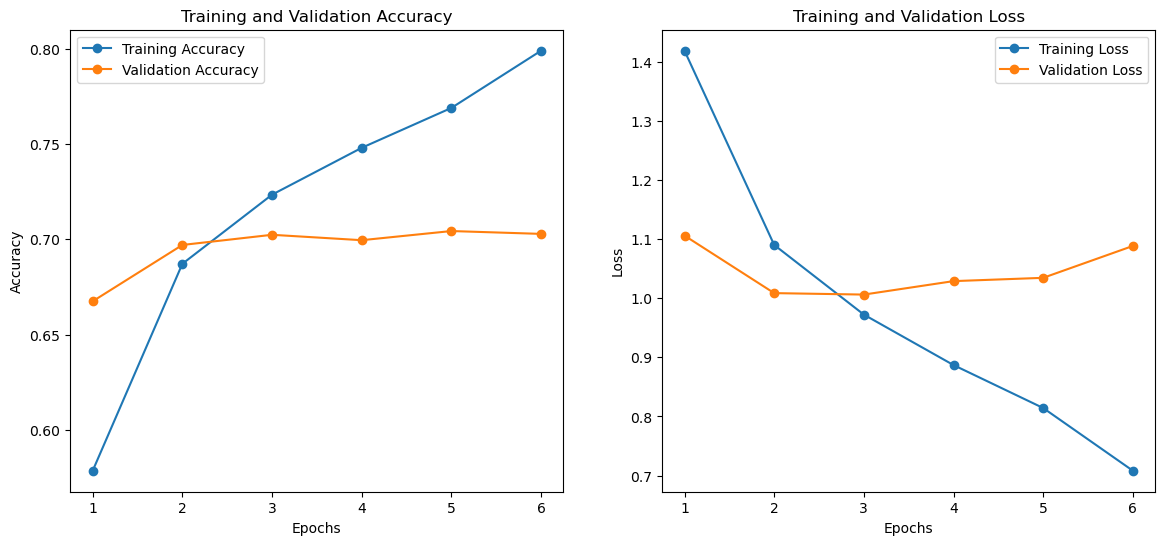

1310/1310 ━━━━━━━━━━━━━━━━━━━━ 73s 56ms/step


In [16]:


# Visualize training and validation loss and accuracy
def plot_training_history(history):
    epochs = range(1, len(history.history['accuracy']) + 1)
    
    # Accuracy plot
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', marker='o')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], label='Training Loss', marker='o')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()

plot_training_history(history)

# Predictions and Real Examples
y_pred = model.predict(X_test_padded)
y_pred_classes = np.argmax(y_pred, axis=1)



In [17]:
# Display predictions and corresponding true labels
def display_predictions(X_test, y_test, y_pred_classes, label_encoder, num_examples=5):
    for i in range(num_examples):
        print(f"Text: {X_test[i]}")
        print(f"True Category: {label_encoder.inverse_transform([y_test[i]])[0]}")
        print(f"Predicted Category: {label_encoder.inverse_transform([y_pred_classes[i]])[0]}")
        print("-" * 60)

display_predictions(X_test[:10], y_test, y_pred_classes, label_encoder)

Headline: divorcing dont let your pet become another casualty of divorce abandoned pets is one of the many sad outcomes of divorce marital problems conflict and ultimately divorce is behind a significant number of pet turnins for animal shelters every year
True Category: MISC
Predicted Category: MISC
------------------------------------------------------------
Headline: how my children have helped me become perfectly human when i became a mom i thought my job was to mold and shape my children into their best selves to my surprise my children have molded and shaped me
True Category: PARENTING AND EDUCATION
Predicted Category: PARENTING AND EDUCATION
------------------------------------------------------------
Headline: alumni feel deja vu on college sexual assault controversies 
True Category: PARENTING AND EDUCATION
Predicted Category: EMPOWERED VOICES
------------------------------------------------------------
Headline: bye bye binary telling my story and being listened to affirmed m